[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana18_Feynman_Kac.ipynb)

# Aplicación de la fórmula de Feynman-Kac


$$ \frac{\partial}{\partial t}u(x,t) + \mu(x,t) \frac{\partial}{\partial x}u(x,t) + \tfrac{1}{2} \sigma^2(x,t) \frac{\partial^2}{\partial x^2}u(x,t) -V(x,t) u(x,t) + f(x,t) = 0$$

con condición final,

$$ u(x,T)=\psi(x)$$

tiene como solución:

$$ u(x,t) = E^Q\left[e^{-\int_t^T V(X_\tau,\tau)\, \mathrm{d}\tau}\psi(X_T) + \int_t^T e^{-\int_t^\tau V(X_s,s)\, \mathrm{d}s}f(X_\tau,\tau)\,\mathrm{d}\tau  \,\Bigg|\, X_t=x \right]$$

donde $X$ es un proceso que satisface

$$ \mathrm{d}X_t = \mu(X_t,t)\,\mathrm{d}t + \sigma(X_t,t)\,\mathrm{d} W^Q_t,$$


En el siguiente ejemplo, consideraremos el caso en que
$$ dX_t = r X_t dt + \sigma X_t dW_t$$

que es el de un geométrico browniano

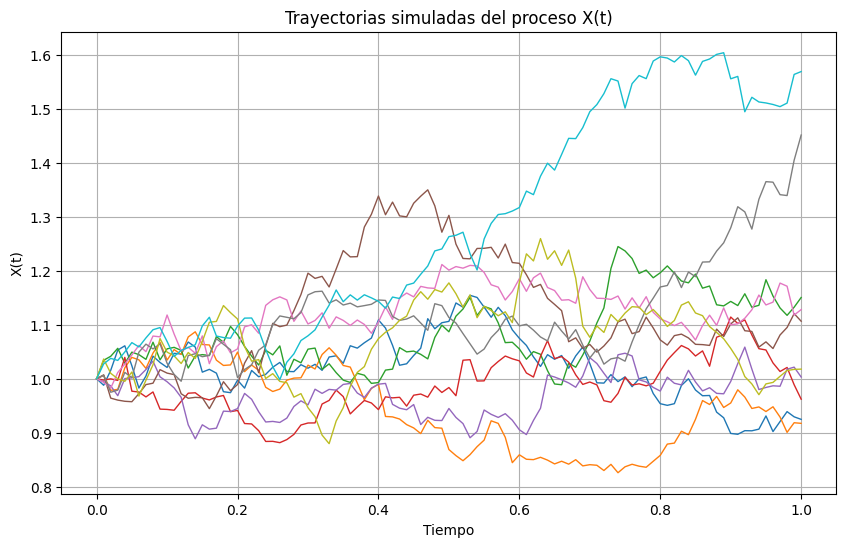

Valor esperado (solución): u(0, x0) = 1.1420


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
mu = 0.1          # Tasa de drift (constante)
sigma = 0.2       # Volatilidad (constante)
T = 1.0           # Tiempo final
N = 100           # Número de pasos en el tiempo
M = 10000         # Número de trayectorias simuladas
x0 = 1.0          # Valor inicial

# Discretización temporal
dt = T / N
t = np.linspace(0, T, N+1)

# Simulación de trayectorias
X = np.zeros((M, N+1))
X[:, 0] = x0

for i in range(1, N+1):
    dW = np.sqrt(dt) * np.random.randn(M)  # Incremento de Wiener
    X[:, i] = X[:, i-1] + mu * X[:, i-1] * dt + sigma * X[:, i-1] * dW

# Evaluación de la condición final: f(X_T) = X_T^2
f_XT = X[:, -1]**2

# Valor esperado bajo la medida neutra al riesgo
u_0 = np.exp(-mu * T) * np.mean(f_XT)

# Gráfica de algunas trayectorias
plt.figure(figsize=(10, 6))
for i in range(10):  # Muestra 10 trayectorias
    plt.plot(t, X[i, :], lw=1)
plt.title('Trayectorias simuladas del proceso X(t)')
plt.xlabel('Tiempo')
plt.ylabel('X(t)')
plt.grid()
plt.show()

print(f"Valor esperado (solución): u(0, x0) = {u_0:.4f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
mu = 0.1          # Tasa de drift (constante)
sigma = 0.2       # Volatilidad (constante)
T = 1.0           # Tiempo final
N = 100           # Número de pasos temporales
M = 10000         # Número de trayectorias simuladas

# Valores de x para evaluar u(1, x)
x_values = np.linspace(0, 2, 50)  # Rango de x para graficar
u_values = []

for x0 in x_values:
    # Simulación de trayectorias para cada x0
    X = np.zeros((M, N + 1))
    X[:, 0] = x0
    dt = T / N
    for i in range(1, N + 1):
        dW = np.sqrt(dt) * np.random.randn(M)  # Incremento de Wiener
        X[:, i] = X[:, i - 1] + mu * X[:, i - 1] * dt + sigma * X[:, i - 1] * dW

    # Condición final: u(T, X(T)) = X(T)^2
    f_XT = X[:, -1]**2

    # Valor esperado descontado para u(1, x0)
    u_Tx = np.mean(f_XT)  # No se descuenta ya que estamos en T=1
    u_values.append(u_Tx)

# Graficar u(1, x) como función de x
plt.figure(figsize=(10, 6))
plt.plot(x_values, u_values, label="Simulación Monte Carlo", color="blue", lw=2)
plt.title("Función $u(1, x)$ vs. $x$")
plt.xlabel("$x$")
plt.ylabel("$u(1, x)$")
plt.legend()
plt.grid()
plt.show()


En este caso, la fórmula nos dice que la solucion es:

$$\mathbb{E} [u(t,X_t)] = e^{-\mu (T - t)} \mathbb{E} [X_t^{2}]$$

# Segunda aplicación

¿Que pasa si consideramos un proceso mas sencillo, como un browniano con deriva?

Es decir, un proceso $X_T$ tal que,

$$ dX_t = \mu dt + \sigma dW_t $$

y pongamos que la condición final es tal que

$$ u(T,x)  = max( x - K, 0)$$



En este caso, Feynman-Kac nos dice que la solución es tal que:

$$ u(t,X_t​) = \mathbb{E} [max(X_T​−K,0)∣Xt​]. $$

con

$$ \mathbb{E} [X_t \vert X_t] = X_t e^{\mu (T-t)}  $$

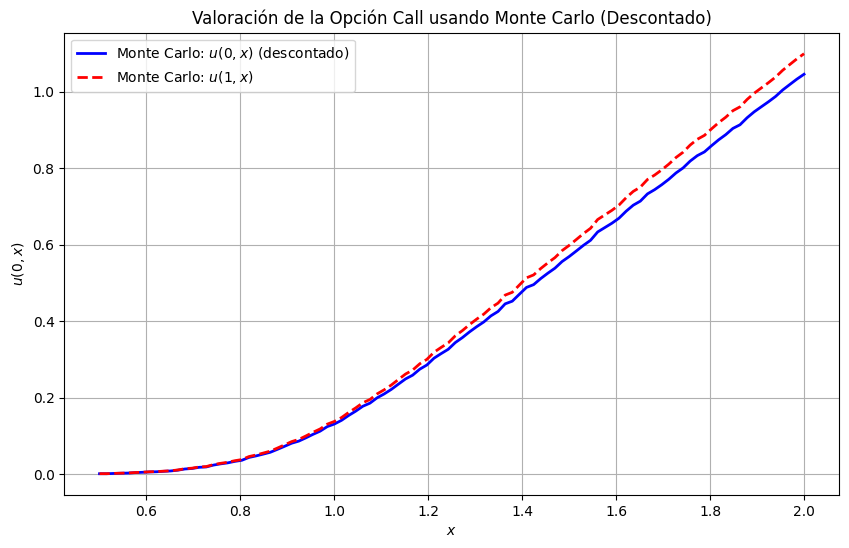

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
mu = 0.1       # Deriva
sigma = 0.2    # Volatilidad
T = 1.0        # Tiempo final (1 año, por ejemplo)
K = 1.0        # Precio de ejercicio (strike price)
r = 0.05       # Tasa de interés libre de riesgo
M = 10000     # Número de trayectorias de Monte Carlo
x_values = np.linspace(0.5, 2.0, 100)  # Valores iniciales para X_0
dt = 0.01      # Paso temporal
N = int(T / dt)  # Número de pasos temporales

# Inicializamos el valor de u(0, x) para cada x
u_values = []
u1_values = []
# Simulación Monte Carlo para cada valor de x
for x0 in x_values:
    # Inicializamos el proceso en t = 0
    X = np.full(M, x0)  # Todas las trayectorias comienzan en x0

    # Simulamos el proceso browniano con deriva hasta t = T
    for _ in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)  # Incrementos brownianos
        X += mu * dt + sigma * dW  # Euler-Maruyama

    # Valoración de la opción call: E[max(X_T - K, 0)]
    call_payoffs = np.maximum(X - K, 0)

    # Descontamos el valor esperado de la opción call
    discounted_value = np.mean(call_payoffs) * np.exp(-r * T)
    u_values.append(discounted_value)  # Promedio de los pagos descontados de la opción call
    u1_values.append(np.mean(call_payoffs))
# Convertimos u_values a un array para graficar
u_values = np.array(u_values)

# Graficamos u(0, x) descontado y el valor de la opción call
plt.figure(figsize=(10, 6))
plt.plot(x_values, u_values, label="Monte Carlo: $u(0, x)$ (descontado)", color="blue", lw=2)
plt.plot(x_values, u1_values, label="Monte Carlo: $u(1,x)$", linestyle="--", color="red", lw=2)
plt.title("Valoración de la Opción Call usando Monte Carlo (Descontado)")
plt.xlabel("$x$")
plt.ylabel("$u(0, x)$")
plt.legend()
plt.grid()
plt.show()



# Preguntas

Viendo la ecuación del browniano geometrico y del browniano con deriva, ¿Porque creen que se utiliza el browniano geometrico para modelar los precios de los activos?

